## Importing Library

In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### Training Image Preprocessing

In [8]:
training_set = tf.keras.utils.image_dataset_from_directory(
    r"Dataset/Plant_dataset/train",
    labels="inferred",          # label = directory name 
    label_mode="categorical",   # Because we have more than 2 classes
    class_names=None,           # If None, it will use the directory names as class names
    color_mode="rgb",
    batch_size=32,              # Number of images to be yielded from the generator per batch
    image_size=(128, 128),      # Resize the images to 128x128
    shuffle=True,               # reduce bias in the training data
    seed=None,      
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 69768 files belonging to 38 classes.


### Validation Image Preprocessing

In [9]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    r"Dataset/Plant_dataset//valid",
    labels="inferred", # label = directory name 
    label_mode="categorical", # Because we have more than 2 classes
    class_names=None, # If None, it will use the directory names as class names
    color_mode="rgb",
    batch_size=32, # Number of images to be yielded from the generator per batch
    image_size=(128, 128), # Resize the images to 128x128
    shuffle=True, # reduce bias in the training data
    seed=None, 
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17452 files belonging to 38 classes.


In [10]:
training_set

<BatchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [11]:
validation_set

<BatchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [12]:
for x,y in training_set.take(1):
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[105.25  95.25 104.25]
   [103.75  93.75 102.75]
   [112.25 102.25 111.25]
   ...
   [137.   132.   139.  ]
   [145.   140.   147.  ]
   [147.5  142.5  149.5 ]]

  [[109.75  99.75 108.75]
   [109.5   99.5  108.5 ]
   [115.75 105.75 114.75]
   ...
   [145.25 140.25 147.25]
   [141.   136.   143.  ]
   [149.   144.   151.  ]]

  [[113.5  103.5  112.5 ]
   [108.5   98.5  107.5 ]
   [119.5  109.5  118.5 ]
   ...
   [146.25 141.25 148.25]
   [137.   132.   139.  ]
   [146.25 141.25 148.25]]

  ...

  [[122.25 113.25 116.25]
   [121.5  112.5  115.5 ]
   [126.5  117.5  122.5 ]
   ...
   [158.25 153.25 159.25]
   [161.75 156.75 162.75]
   [160.   155.   161.  ]]

  [[127.25 118.25 121.25]
   [131.25 122.25 125.25]
   [135.25 126.25 131.25]
   ...
   [160.5  155.5  161.5 ]
   [163.5  158.5  164.5 ]
   [158.25 153.25 159.25]]

  [[122.   113.   116.  ]
   [127.   118.   121.  ]
   [126.25 117.25 122.25]
   ...
   [163.75 158.75 164.75]
   [156.75 151.75 157.75]
   [158.75 153.75 15

###  To avoid Overshooting
1. Choose Small learning rate default 0.001 we are taking 0.0001
2. There may be chance of Underfitting ,  so increase numbers of nueron
3. Add more conolution Layaer to extract more features from image there may be possibility that model unable to capture relevant feauture or model is confusing due to lack of feature so feed with more feature.

## Building Model

In [13]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

### Building Convulation Layer

In [14]:
model = Sequential()
model.add(Conv2D(32,(3,3),padding="same",activation="relu",input_shape=(128,128,3))    )
model.add(Conv2D(32,(3,3),activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2),strides=2))

In [15]:
model.add(Conv2D(64,(3,3),padding="same",activation="relu",input_shape=(128,128,3))    )
model.add(Conv2D(64,(3,3),activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2),strides=2))


In [16]:
model.add(Conv2D(128,(3,3),padding="same",activation="relu",input_shape=(128,128,3))    )
model.add(Conv2D(128,(3,3),activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2),strides=2))

In [17]:
model.add(Conv2D(256,(3,3),padding="same",activation="relu",input_shape=(128,128,3))    )
model.add(Conv2D(256,(3,3),activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2),strides=2))

In [18]:
model.add(Conv2D(512,(3,3),padding="same",activation="relu",input_shape=(128,128,3))    )
model.add(Conv2D(512,(3,3),activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2),strides=2))

In [19]:
model.add(Dropout(0.25)) # To prevent overfitting

In [20]:
model.add(Flatten())

In [21]:
model.add(Dense(units=1500,activation="relu"))

In [22]:
model.add(Dropout(0.4))

In [23]:
#Output Layer
model.add(Dense(units=38,activation="softmax"))

### Compiling My model

In [24]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss="categorical_crossentropy",metrics=["accuracy"])

In [25]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 63, 63, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                    

### Model Training

In [26]:
training_history = model.fit(training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
2181/2181 [==============================] - 278s 119ms/step - loss: 1.3559 - accuracy: 0.6030 - val_loss: 0.6351 - val_accuracy: 0.7997
Epoch 2/10
2181/2181 [==============================] - 230s 106ms/step - loss: 0.4305 - accuracy: 0.8641 - val_loss: 0.3157 - val_accuracy: 0.8983
Epoch 3/10
2181/2181 [==============================] - 230s 105ms/step - loss: 0.2608 - accuracy: 0.9161 - val_loss: 0.2049 - val_accuracy: 0.9321
Epoch 4/10
2181/2181 [==============================] - 228s 105ms/step - loss: 0.1754 - accuracy: 0.9429 - val_loss: 0.2007 - val_accuracy: 0.9355
Epoch 5/10
2181/2181 [==============================] - 214s 98ms/step - loss: 0.1309 - accuracy: 0.9563 - val_loss: 0.1962 - val_accuracy: 0.9384
Epoch 6/10
2181/2181 [==============================] - 206s 94ms/step - loss: 0.1042 - accuracy: 0.9662 - val_loss: 0.1995 - val_accuracy: 0.9383
Epoch 7/10
2181/2181 [==============================] - 203s 93ms/step - loss: 0.0858 - accuracy: 0.9719 - val_los

## Model Saving

In [27]:
model.save("Plant_disease_model.keras")
model.save("Plant_disease_model.h5")

## Model Evaluation

In [28]:
# Model Evaluation on training set
train_loss,train_acc = model.evaluate(training_set)

2181/2181 [==============================] - 71s 33ms/step - loss: 0.0154 - accuracy: 0.9954


In [29]:
print("Training Loss: ",train_loss)
print("Training Accuracy: ",train_acc)

Training Loss:  0.015430604107677937
Training Accuracy:  0.9953703880310059


In [30]:
val_loss,val_acc = model.evaluate(validation_set)

546/546 [==============================] - 18s 33ms/step - loss: 0.0922 - accuracy: 0.9717


In [31]:
print("Validation Loss: ",val_loss)
print("Validation Accuracy: ",val_acc)

Validation Loss:  0.09224484115839005
Validation Accuracy:  0.9716938138008118


In [32]:
training_history.history

{'loss': [1.3559024333953857,
  0.4304685890674591,
  0.26076215505599976,
  0.1753845363855362,
  0.13089017570018768,
  0.10420938581228256,
  0.0858159065246582,
  0.07704722881317139,
  0.061081450432538986,
  0.0563778392970562],
 'accuracy': [0.6030415296554565,
  0.8640924096107483,
  0.9160933494567871,
  0.9428964853286743,
  0.9562693238258362,
  0.9662166237831116,
  0.971863865852356,
  0.9754185080528259,
  0.97990483045578,
  0.9817251563072205],
 'val_loss': [0.6350665092468262,
  0.3157193064689636,
  0.20489661395549774,
  0.20069821178913116,
  0.1961851716041565,
  0.1994737982749939,
  0.16707338392734528,
  0.19520439207553864,
  0.11225583404302597,
  0.09224484115839005],
 'val_accuracy': [0.7996791005134583,
  0.8983497619628906,
  0.932099461555481,
  0.9354801774024963,
  0.9384024739265442,
  0.9382878541946411,
  0.9493467807769775,
  0.9432729482650757,
  0.9663075804710388,
  0.9716938138008118]}

In [33]:
import json 
with open("training_history.json","w") as f:
    json.dump(training_history.history,f)

### Accuracy Visualization

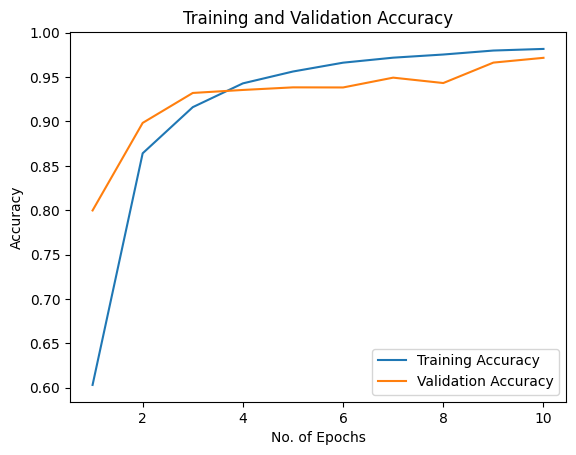

In [34]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history["accuracy"],label="Training Accuracy")
plt.plot(epochs,training_history.history["val_accuracy"],label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#### Some other metrics for model evaluation

In [35]:
class_name =  validation_set.class_names

In [36]:
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [38]:
test_set = tf.keras.utils.image_dataset_from_directory(
    r"Dataset/Plant_dataset//valid",
    labels="inferred", # label = directory name 
    label_mode="categorical", # Because we have more than 2 classes
    class_names=None, # If None, it will use the directory names as class names
    color_mode="rgb",
    batch_size=32, # Number of images to be yielded from the generator per batch
    image_size=(128, 128), # Resize the images to 128x128
    shuffle=False, # reduce bias in the training data
    seed=None, 
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17452 files belonging to 38 classes.


In [39]:
y_pred = model.predict(test_set)

546/546 [==============================] - 17s 31ms/step


In [40]:
y_pred

array([[9.9999988e-01, 1.5381958e-12, 1.3170269e-12, ..., 1.2047803e-17,
        1.7651316e-16, 1.9908153e-13],
       [1.0000000e+00, 2.9875120e-14, 8.1207491e-13, ..., 3.7429861e-18,
        3.8002206e-17, 6.8964012e-15],
       [1.0000000e+00, 3.7274813e-19, 1.3305223e-16, ..., 6.9358845e-26,
        7.2355887e-22, 1.2075497e-18],
       ...,
       [4.8994923e-11, 1.6339960e-12, 3.1719929e-09, ..., 5.2377332e-11,
        1.4895976e-10, 9.9999917e-01],
       [8.8472840e-12, 8.4080694e-16, 1.5316322e-12, ..., 1.1099029e-12,
        3.1078856e-13, 1.0000000e+00],
       [3.3903149e-18, 1.1277170e-19, 7.3357950e-18, ..., 2.3117711e-20,
        3.6141105e-18, 1.0000000e+00]], dtype=float32)

In [41]:
y_pred.shape

(17452, 38)

In [42]:
predicted_categories = tf.argmax(y_pred,axis=1)

In [43]:
print(predicted_categories)

tf.Tensor([ 0  0  0 ... 37 37 37], shape=(17452,), dtype=int64)


In [44]:
true_categories = tf.concat([y for x,y in test_set],axis=0)

In [45]:
true_categories

<tf.Tensor: shape=(17452, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [46]:
Y_true = tf.argmax(true_categories,axis=1)

In [47]:
Y_true

<tf.Tensor: shape=(17452,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [48]:
from sklearn.metrics import classification_report , confusion_matrix
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.96      0.98      0.97       504
                                 Apple___Black_rot       1.00      0.98      0.99       497
                          Apple___Cedar_apple_rust       0.93      1.00      0.96       440
                                   Apple___healthy       0.96      0.96      0.96       502
                               Blueberry___healthy       0.99      0.95      0.97       454
          Cherry_(including_sour)___Powdery_mildew       0.99      1.00      0.99       421
                 Cherry_(including_sour)___healthy       0.97      0.99      0.98       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.93      0.87      0.90       290
                       Corn_(maize)___Common_rust_       1.00      0.99      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.94      0.96      0.

In [49]:
cm = confusion_matrix(Y_true,predicted_categories)

In [50]:
print(cm)

[[493   0   1 ...   0   0   0]
 [  1 488   2 ...   0   0   0]
 [  0   0 438 ...   0   0   1]
 ...
 [  0   0   0 ... 485   0   0]
 [  0   0   0 ...   0 446   0]
 [  0   0   1 ...   0   0 479]]


In [51]:
cm.shape

(38, 38)

### Visualization of Confusion matrix

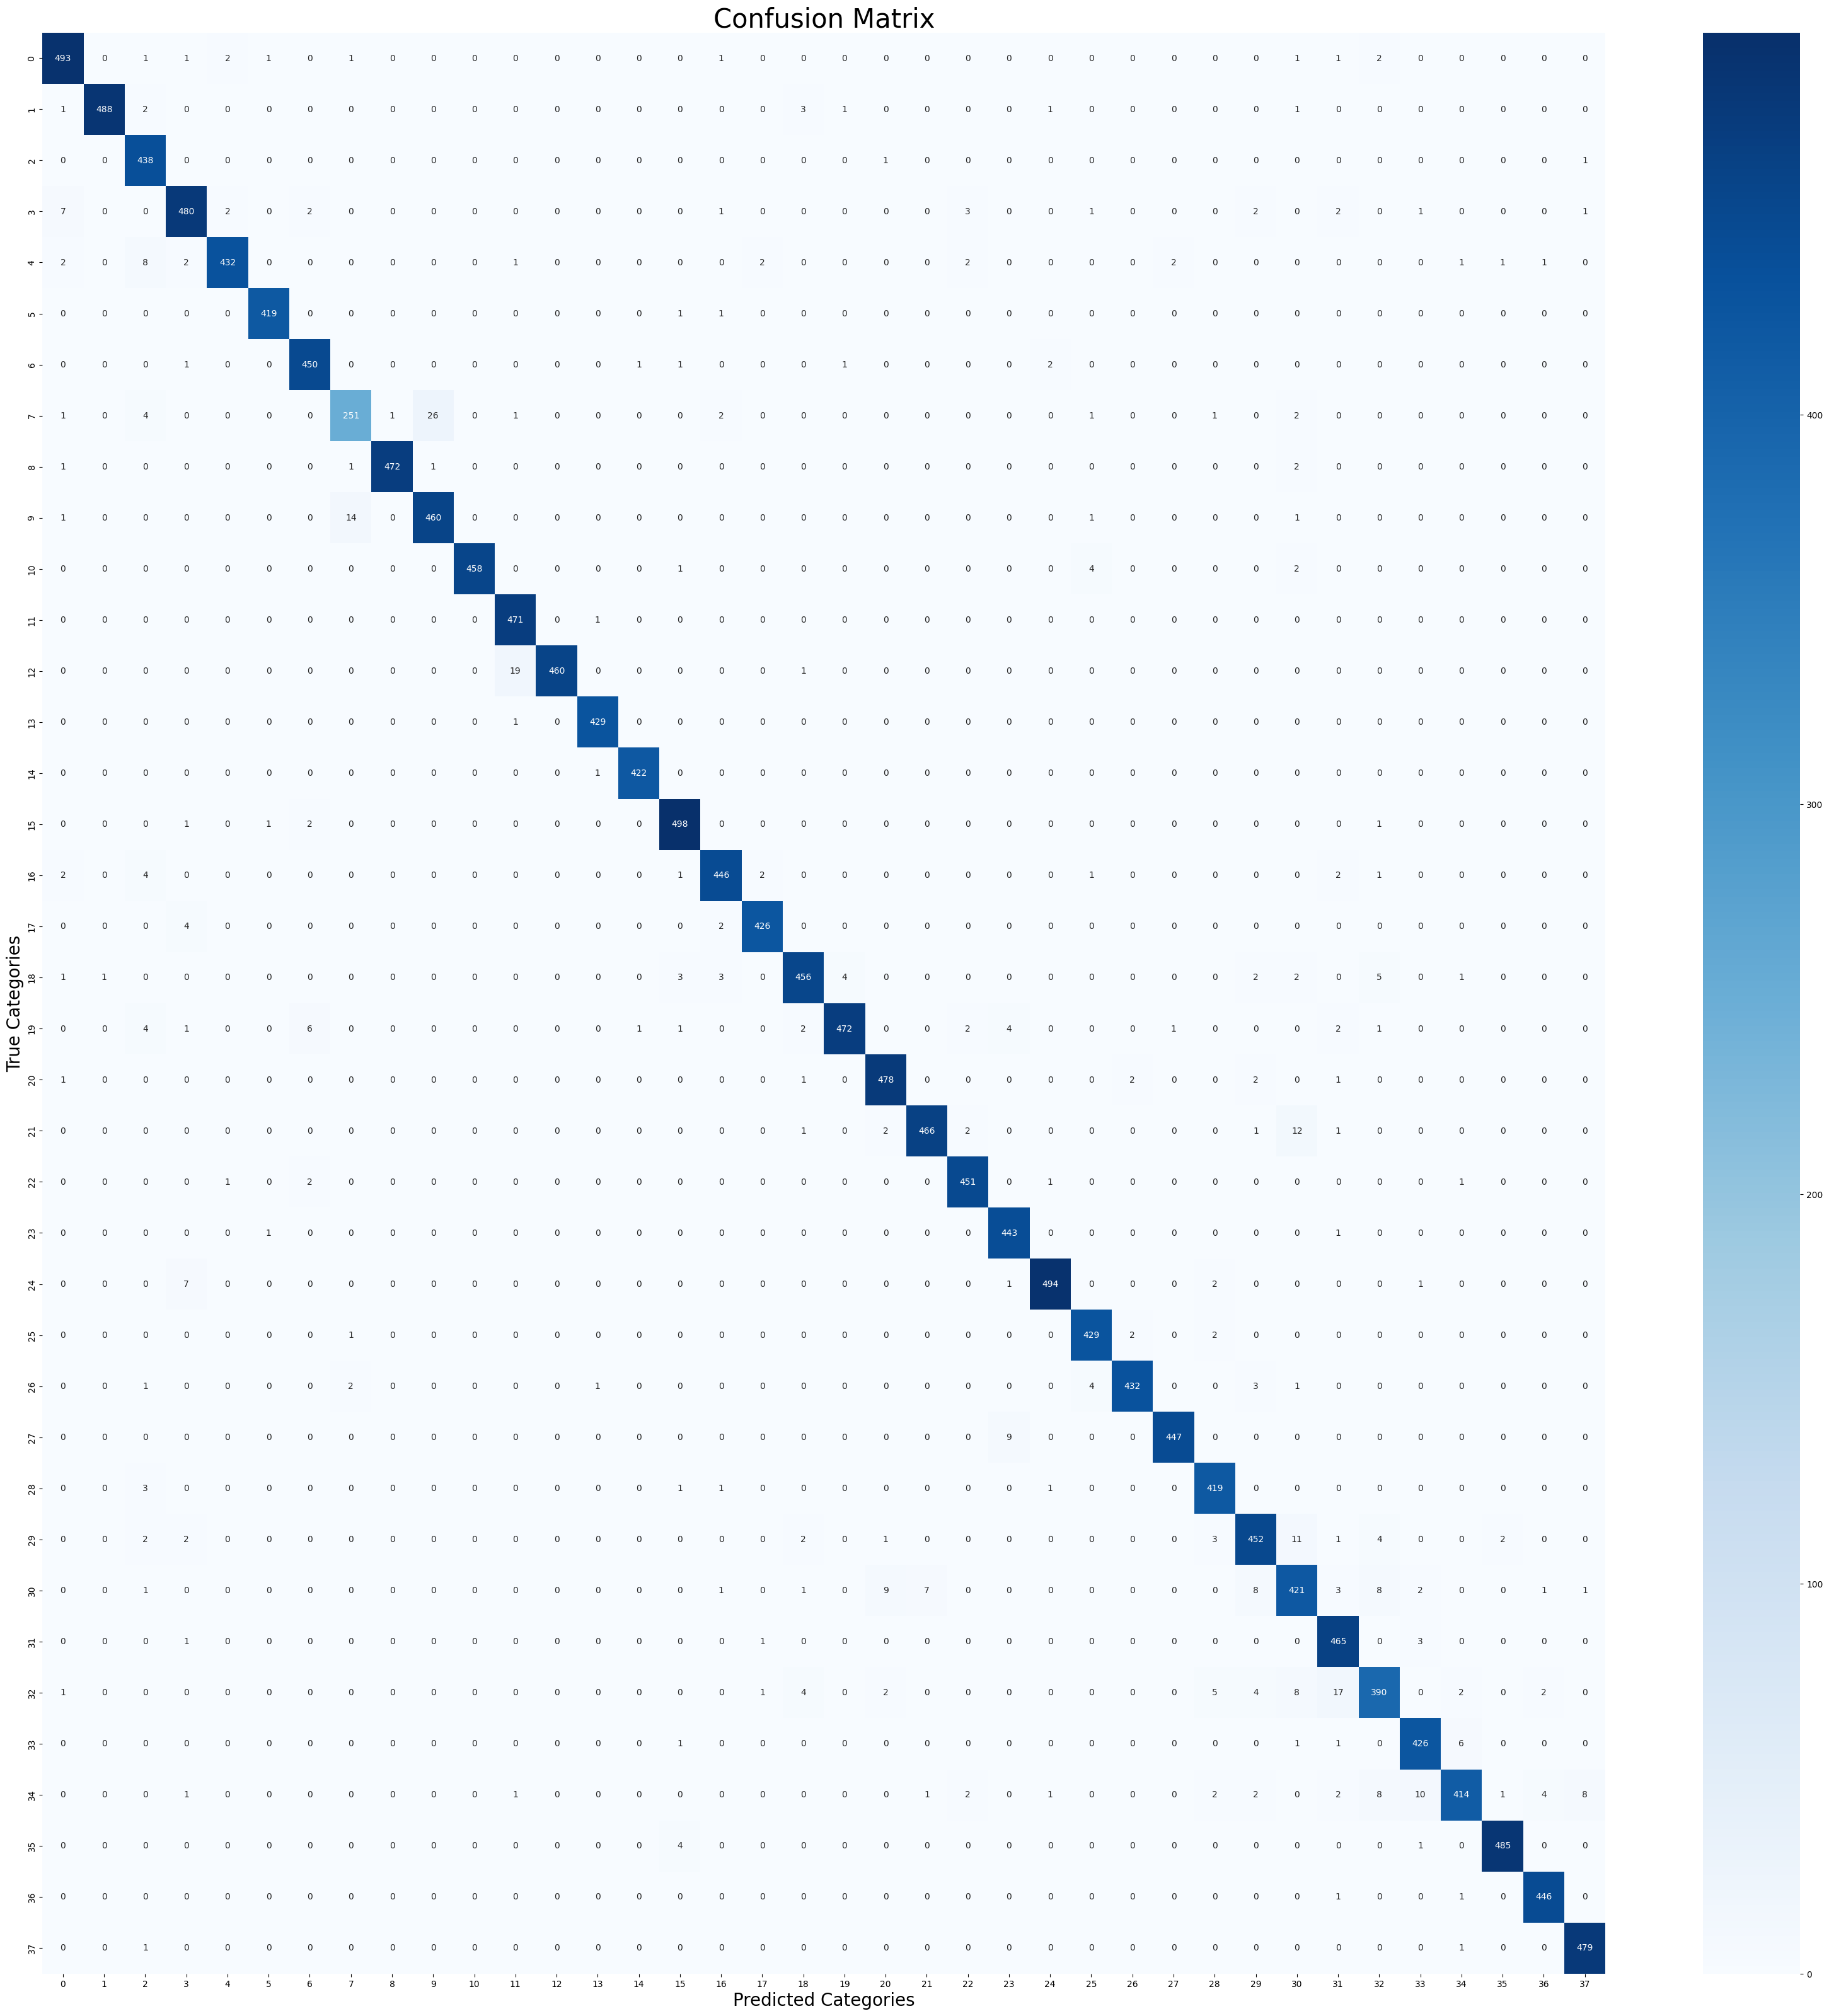

In [52]:
plt.figure(figsize=(40,40))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix",fontsize=30)
plt.xlabel("Predicted Categories",fontsize=20)
plt.ylabel("True Categories",fontsize=20)
plt.show()